In [13]:
import pandas as pd 
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:


def parse_result_files(directory_path):
    all_rows = []

    # Regex optimisées
    re_runtime = re.compile(r"Run-time:\s+([\d.]+)")
    re_memory = re.compile(r"Total allocated memory size:\s+([\d.]+)")
    re_algorithm = re.compile(r"Algorithm:\s+(.*?)(?:\s\(|$)")
    re_file = re.compile(r"File:\s+.*/([^/]+)\.csv")
    re_min_support = re.compile(r"Minimum support:\s+([\d.]+)")
    
    if not os.path.exists(directory_path):
        print(f"Erreur : Le dossier '{directory_path}' est introuvable.")
        return pd.DataFrame()

    for filename in os.listdir(directory_path):
        if filename.endswith(".txt"):
            file_path = os.path.join(directory_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                
                # 1. Extraction des métadonnées
                runtime = re_runtime.search(content)
                memory = re_memory.search(content)
                algo = re_algorithm.search(content)
                dataset_match = re_file.search(content)
                min_supp_val = re_min_support.search(content)

                # 2. Mapping des variables (Dictionnaire de traduction)
                var_mapping = {}
                var_lines = re.findall(r"(\d+)\.\s+(.*)", content)
                for idx, name in var_lines:
                    var_mapping[idx] = name.strip()

                # 3. Extraction des patterns
                # On cible la zone entre 'Pattern : Support' et le prochain bloc 'Iteration' ou fin de fichier
                pattern_section = re.search(r"Pattern : Support\n(.*?)(?:\n\n|\nIteration|$)", content, re.DOTALL)
                
                list_motifs_traduits = []
                list_supports_motifs = []
                
                if pattern_section:
                    patterns_raw = pattern_section.group(1).strip().split('\n')
                    for line in patterns_raw:
                        if ':' in line:
                            pattern_str, supp_val = line.split(':')
                            
                            # Support individuel du motif
                            list_supports_motifs.append(float(supp_val.strip()))
                            
                            # Traduction : ['0+', '1-'] -> ['Age+', 'ALB-']
                            items = pattern_str.strip().replace("'", "").replace("[", "").replace("]", "").split(", ")
                            translated = []
                            for item in items:
                                if item: # Évite les résidus vides
                                    suffix = item[-1]
                                    prefix = item[:-1]
                                    real_name = var_mapping.get(prefix, prefix)
                                    translated.append(f"{real_name}{suffix}")
                            
                            list_motifs_traduits.append(translated)

                # 4. Construction de la ligne
                all_rows.append({
                    "Dataset": dataset_match.group(1) if dataset_match else filename.split('_')[2], # Fallback sur le nom du fichier
                    "Algorithm": algo.group(1) if algo else "GA-GRAANK",
                    "Support": float(min_supp_val.group(1)) if min_supp_val else 0.0,
                    "Run-time (s)": float(runtime.group(1)) if runtime else 0.0,
                    "Memory (KiB)": float(memory.group(1)) if memory else 0.0,
                    "Nb Motifs": len(list_motifs_traduits), # Nouvelle colonne
                    "Supports motifs": list_supports_motifs,
                    "Motifs détectés": list_motifs_traduits
                })

    # Création du DataFrame
    df = pd.DataFrame(all_rows)
    
    # Tri pour une meilleure lisibilité : par Dataset, puis par Support croissant
    if not df.empty:
        df = df.sort_values(by=["Dataset", "Support"]).reset_index(drop=True)
    
    return df

df_resultats = parse_result_files('../results1_final/')
print(df_resultats[['Dataset', 'Support', 'Nb Motifs', 'Run-time (s)']].head())

      Dataset  Support  Nb Motifs  Run-time (s)
0  Cargo_2000     0.30          4    432.569791
1  Cargo_2000     0.30          3     36.599103
2  Cargo_2000     0.30          1    679.313070
3  Cargo_2000     0.34          3     46.227277
4  Cargo_2000     0.34          4    428.152063


['Cargo_2000' 'Chickenpox' 'HCV' 'air_quality']


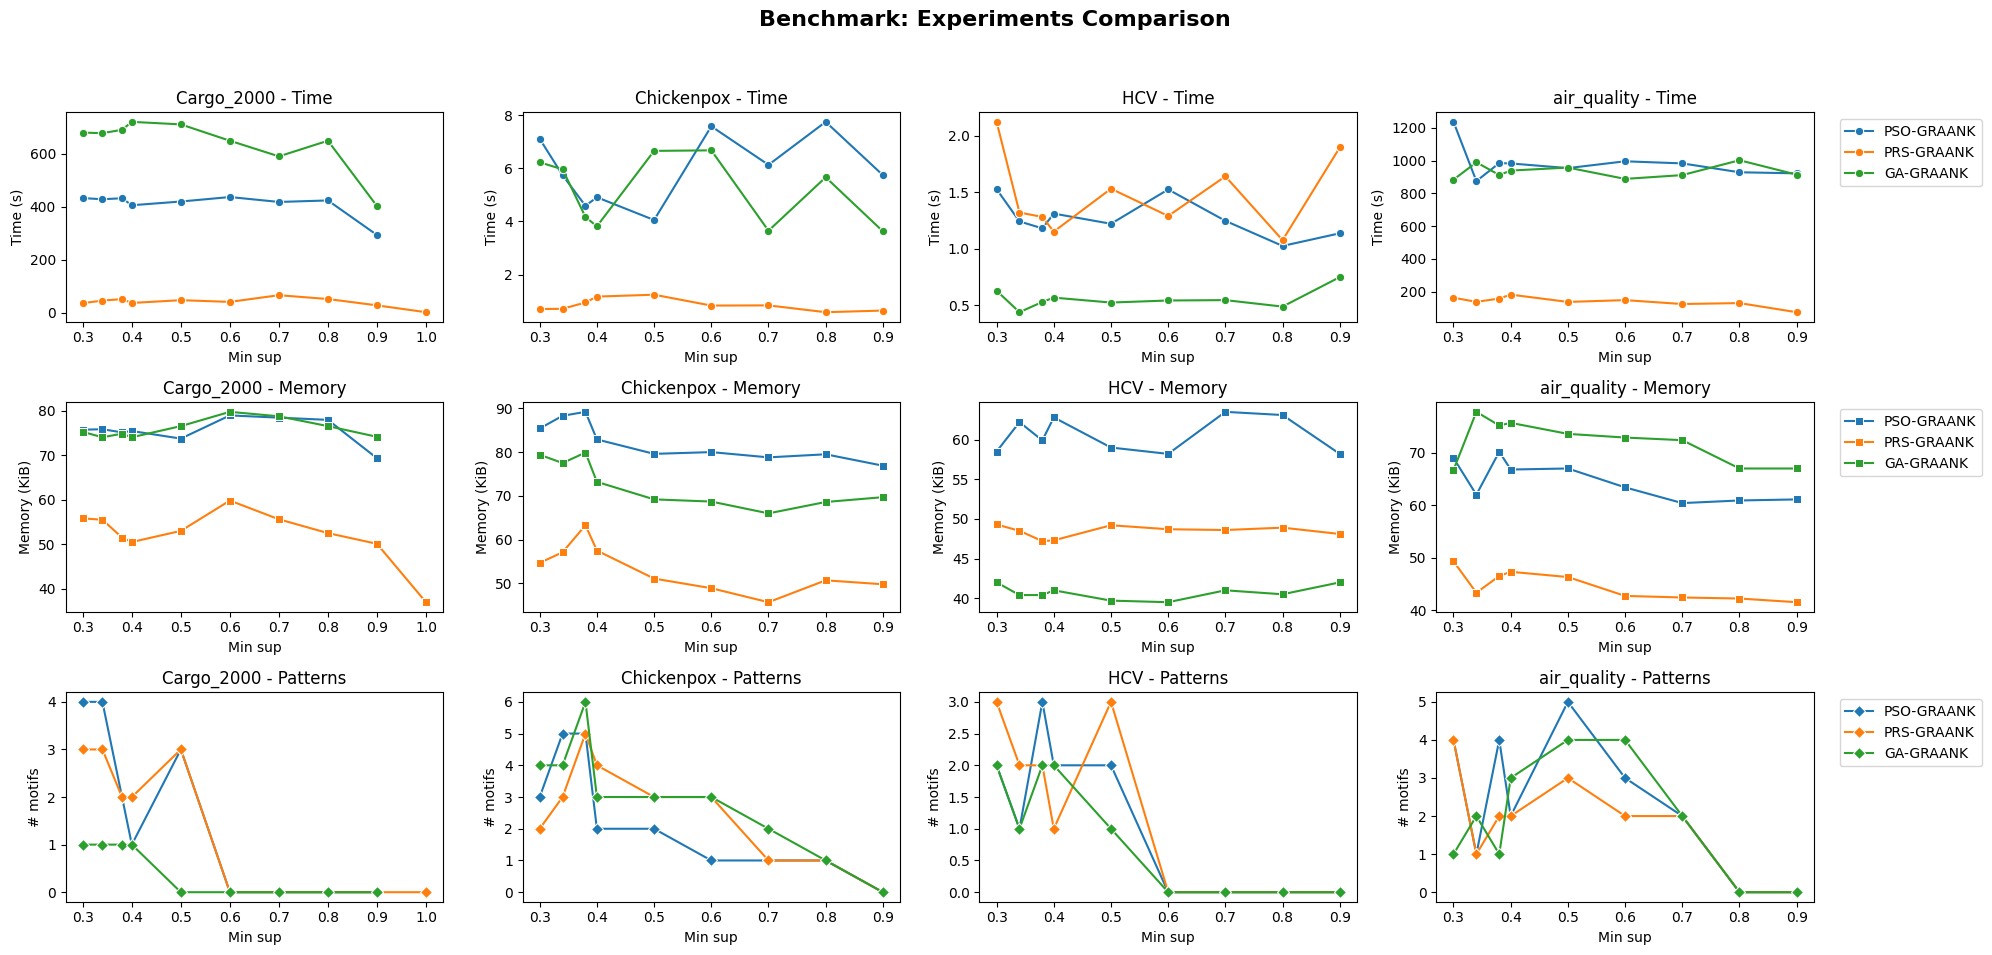

In [ ]:


def plot_metrics(df, filenames, algorithme_name='Experiments Comparison', 
                 col_supp='Support', col_time='Run-time (s)', 
                 col_memory='Memory (KiB)', col_candidate='Nb Motifs', 
                 n_rows=3, figsize=(20, 10)):
    
    # Le nombre de colonnes doit correspondre au nombre de datasets à afficher
    n_cols = len(filenames)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    

    hue_col = 'Algorithm' 

    for i, file in enumerate(filenames):
        # Filtrage par dataset
        df_tmp = df[df['Dataset'] == file]
       
        if df_tmp.empty:
            print(f"Attention : Aucune donnée pour le fichier {file}")
            continue

        # --- Ligne 0 : TEMPS D'EXÉCUTION ---
        sns.lineplot(data=df_tmp, x=col_supp, y=col_time, hue=hue_col, ax=axes[0, i], marker='o')
        axes[0, i].set_title(f"{file} - Time")
        axes[0, i].set_xlabel("Min sup")
        axes[0, i].set_ylabel("Time (s)")
        
        # --- Ligne 1 : MÉMOIRE ---
        sns.lineplot(data=df_tmp, x=col_supp, y=col_memory, hue=hue_col, ax=axes[1, i], marker='s')
        axes[1, i].set_title(f"{file} - Memory")
        axes[1, i].set_xlabel("Min sup")
        axes[1, i].set_ylabel("Memory (KiB)")

        sns.lineplot(data=df_tmp, x=col_supp, y=col_candidate, hue=hue_col, ax=axes[2, i], marker='D')
        axes[2, i].set_title(f"{file} - Patterns")
        axes[2, i].set_xlabel("Min sup")
        axes[2, i].set_ylabel("# motifs")
        

        
        if i < n_cols - 1:
            axes[0, i].get_legend().remove()
            axes[1, i].get_legend().remove()
            axes[2, i].get_legend().remove()
        else:
            # Place la légende à l'extérieur à droite
            for row in range(3):
                if axes[row, i].get_legend():
                    axes[row, i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(f"Benchmark: {algorithme_name}", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustement pour le titre principal
    
    
    plt.show()

datasets_to_plot = df_resultats['Dataset'].unique()
print(datasets_to_plot)
plot_metrics(df_resultats, datasets_to_plot)

In [16]:
df_resultats

,Dataset,Algorithm,Support,Run-time (s),Memory (KiB),Nb Motifs,Supports motifs,Motifs détectés
0,Cargo_2000,PSO-GRAANK,0.30,432.569791,75.7,4,"[0.491, 0.357, 0.422, 0.407]","[[i1_legid+, i1_rcs_e-], [i1_legid+, i1_rcs_p+..."
1,Cargo_2000,PRS-GRAANK,0.30,36.599103,55.8,3,"[0.494, 0.421, 0.301]","[[i1_legid+, i1_rcs_p-], [i1_legid+, i1_dep_1_..."
2,Cargo_2000,GA-GRAANK,0.30,679.313070,75.2,1,[0.306],"[[i1_legid-, i1_rcs_e+, i1_rcf_1_p+]]"
3,Cargo_2000,PRS-GRAANK,0.34,46.227277,55.5,3,"[0.421, 0.407, 0.508]","[[i1_legid+, i1_dep_1_p+], [i1_legid+, i1_rcs_..."
4,Cargo_2000,PSO-GRAANK,0.34,428.152063,75.8,4,"[0.407, 0.506, 0.422, 0.421]","[[i1_legid+, i1_rcs_p-, i1_rcs_e-], [i1_legid+..."
...,...,...,...,...,...,...,...,...
104,air_quality,PRS-GRAANK,0.80,130.216456,42.2,0,[],[]
105,air_quality,PSO-GRAANK,0.80,929.439042,60.9,0,[],[]
106,air_quality,PRS-GRAANK,0.90,74.525823,41.5,0,[],[]
107,air_quality,PSO-GRAANK,0.90,922.934965,61.1,0,[],[]


In [17]:
df2 = pd.read_csv("result_pca.csv")

In [18]:
df2

,Dataset,Algorithm,Support,Run-time (s),Memory (KiB),Nb Motifs,Supports motifs,Motifs détectés
0,HCV,GRAANK,0.30,9.638912,50.364258,150,0,NaN
1,HCV,GRAANK,0.34,9.240743,39.067383,120,0,NaN
2,HCV,GRAANK,0.38,8.967299,30.809570,94,0,NaN
3,HCV,GRAANK,0.40,8.862499,30.036133,94,0,NaN
4,HCV,GRAANK,0.50,7.565296,20.431641,48,0,NaN
...,...,...,...,...,...,...,...,...
76,Chickenpox,PCA-GRAANK,0.60,8.494632,38.968750,112,0,NaN
77,Chickenpox,PCA-GRAANK,0.70,7.503642,19.597656,44,0,NaN
78,Chickenpox,PCA-GRAANK,0.80,7.109069,4.356445,0,0,NaN
79,Chickenpox,PCA-GRAANK,0.90,7.121989,4.856445,0,0,NaN


In [19]:
import numpy as np

In [20]:
df = pd.concat([df_resultats, df2], axis=0)
df.Dataset = np.where(df['Dataset'] =="air_quality", "Air Quality", df["Dataset"] )
df.Dataset = np.where(df['Dataset'] =="Cargo_2000", "Cargo 2000", df["Dataset"] )

ok


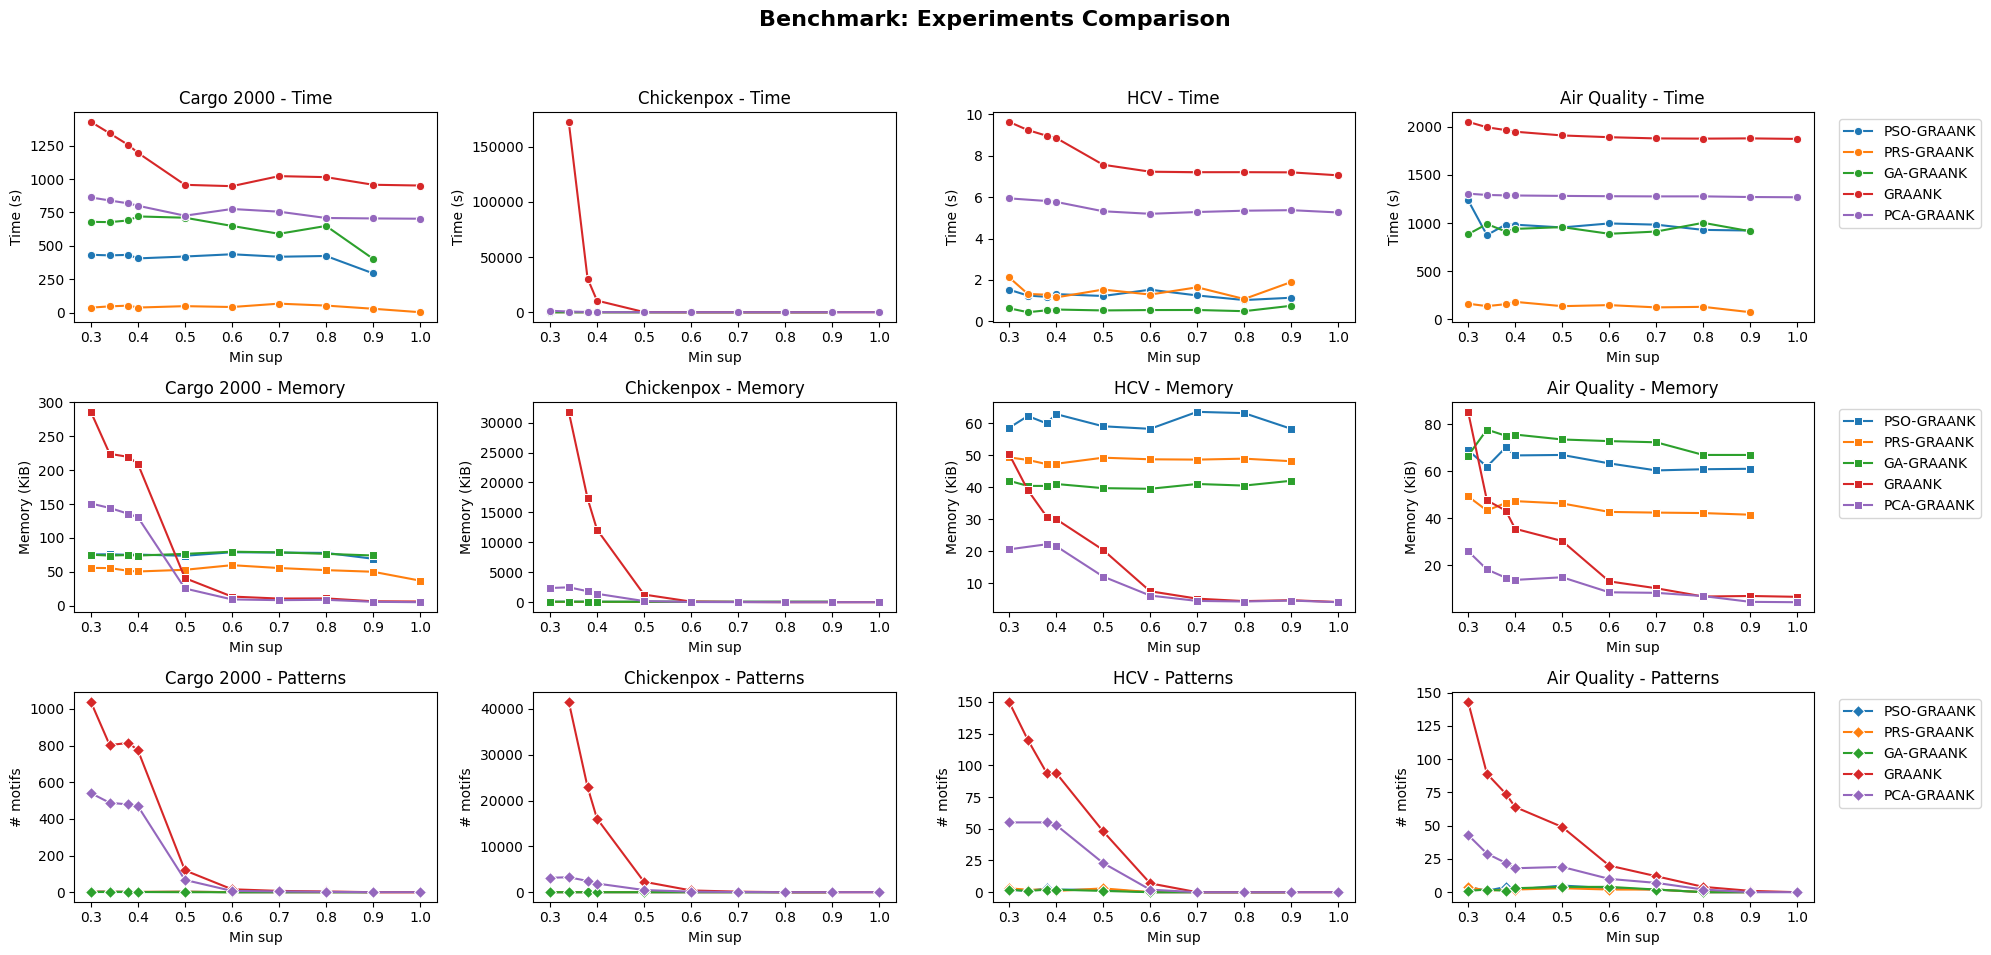

In [21]:

datasets_to_plot = df['Dataset'].unique()
plot_metrics(df, datasets_to_plot)

In [22]:
datasets_to_plot

array(['Cargo 2000', 'Chickenpox', 'HCV', 'Air Quality'], dtype=object)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


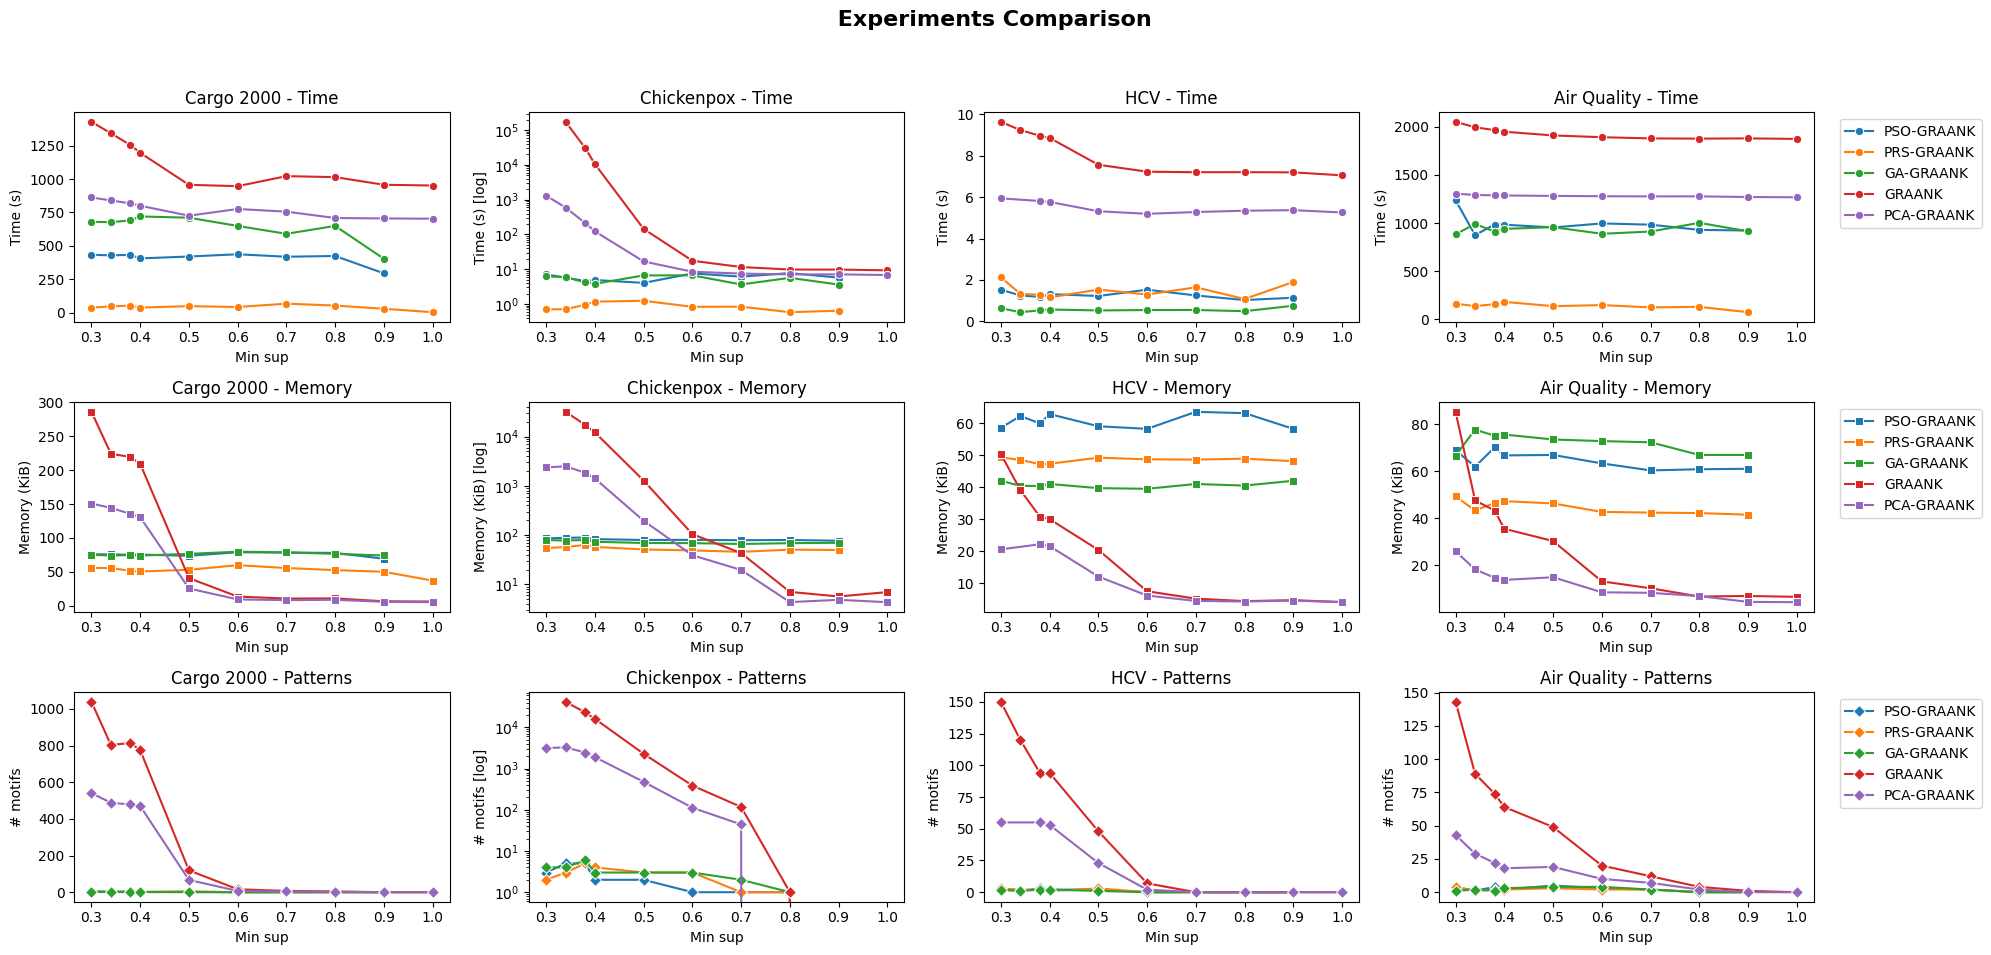

In [39]:
def plot_metrics(df, filenames, algorithme_name='Experiments Comparison', 
                 col_supp='Support', col_time='Run-time (s)', 
                 col_memory='Memory (KiB)', col_candidate='Nb Motifs', 
                 n_rows=3, figsize=(20, 10),
                 log_scale_datasets=None):  # nouveau paramètre
    
    if log_scale_datasets is None:
        log_scale_datasets = []
    
    n_cols = len(filenames)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)

    hue_col = 'Algorithm' 

    for i, file in enumerate(filenames):
        df_tmp = df[df['Dataset'] == file]
        if df_tmp.empty:
            print(f"Attention : Aucune donnée pour le fichier {file}")
            continue
        
        
        

        use_log = file in log_scale_datasets  
        
        #if file =="Chickenpox" :
            #print(df_tmp[[col_supp, col_candidate, col_time, "Dataset"]])
            
            

        # --- Ligne 0 : TEMPS D'EXÉCUTION ---
        sns.lineplot(data=df_tmp, x=col_supp, y=col_time, hue=hue_col, ax=axes[0, i], marker='o')
        axes[0, i].set_title(f"{file} - Time")
        axes[0, i].set_xlabel("Min sup")
        axes[0, i].set_ylabel("Time (s)" + (" [log]" if use_log else ""))
        if use_log:
            axes[0, i].set_yscale('log')
        
        # --- Ligne 1 : MÉMOIRE ---
        sns.lineplot(data=df_tmp, x=col_supp, y=col_memory, hue=hue_col, ax=axes[1, i], marker='s')
        axes[1, i].set_title(f"{file} - Memory")
        axes[1, i].set_xlabel("Min sup")
        axes[1, i].set_ylabel("Memory (KiB)" + (" [log]" if use_log else ""))
        if use_log:
            axes[1, i].set_yscale('log')

        # --- Ligne 2 : NOMBRE DE MOTIFS ---
        sns.lineplot(data=df_tmp, x=col_supp, y=col_candidate, hue=hue_col, ax=axes[2, i], marker='D')
        axes[2, i].set_title(f"{file} - Patterns")
        axes[2, i].set_xlabel("Min sup")
        axes[2, i].set_ylabel("# motifs" + (" [log]" if use_log else ""))
        if use_log:
            axes[2, i].set_yscale('log')

        if i < n_cols - 1:
            axes[0, i].get_legend().remove()
            axes[1, i].get_legend().remove()
            axes[2, i].get_legend().remove()
        else:
            for row in range(3):
                if axes[row, i].get_legend():
                    axes[row, i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.suptitle(f" {algorithme_name} ", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"../../images_conf/{algorithme_name}.eps")
    plt.show()





datasets_to_plot = df['Dataset'].unique()
plot_metrics(df, datasets_to_plot, log_scale_datasets=["Chickenpox"])



In [42]:
#df.to_csv("result_completed.csv", index=False)